<h1>------------------------------------------------------</h1>
<h1>II. Evaluation of deterministic solar forecast quality</h1>
<h1>------------------------------------------------------</h1>

The goodness of a forecast can be assessed by 3 ways as proposed by Murphy [1]:
 * Consistency: correspondance with forecaster best judgment
 * Quality: correspondance with observed conditions
 * Value: economic or other benefits when used in decision makink process

In this course we will only assess the forecast quality by comparing  forecast with corresponding observations and using a set of metrics decribed by Yang et al. [2].
__________

 [1] <i>Murphy, A. H., 1993: What Is a Good Forecast? An Essay on the Nature of Goodness in Weather Forecasting. Wea. Forecasting, 8, 281–293, [https://doi.org/10.1175/1520-0434(1993)008<0281:WIAGFA>2.0.CO;2.](https://doi.org/10.1175/1520-0434(1993)008<0281:WIAGFA>2.0.CO;2)</i>

 [2] <i>Yang, D., Alessandrini, S., Antonanzas, J., Antonanzas-Torres, F., Badescu, V., Beyer, H. G., Blaga, R., Boland, J., Bright, J. M., Coimbra, C. F. M., David, M., Frimane, Â., Gueymard, C. A., Hong, T., Kay, M. J., Killinger, S., Kleissl, J., Lauret, P., Lorenz, E., … Zhang, J. (2020). Verification of deterministic solar forecasts. Solar Energy, 210(20–37), S0038092X20303947. https://doi.org/10.1016/j.solener.2020.04.019</i>

In [1]:
# Load required libraries
import numpy as np # Basic mathematical operators
import pandas as pd # Handle 2D arrays (tables)
import matplotlib.pyplot as plt # Nice plots
import xarray as xr # Handle multidimensionnal arrays
import fsspec # To import data files from online repositories

<h1>------------------------------------------------------</h1>

<h1>Section A: Visual evaluation of deterministic forecast</h1>

In this section we will use a NetCDF file containing multiple sources of forecast (NWP, satellite and persistence), the corresponding observations and the clear sky conditions and covering 6 month from July 1st to December 31st 2022. Unlike the previous forecasting data, we will use a single point located in the south-west part of La Reunion where high quality solar measurments are available (21.333°S, 51,483°E, 75m, UTC+4h).

In [2]:
# Dowload and copy the required data file from GitHub (https://github.com/Laboratoire-Piment/Probabilistic_solar_forecast_lesson)
destination = "temp/sat_nwp_pers_1h.nc"
fs = fsspec.filesystem("github", org="Laboratoire-Piment", repo="Probabilistic_solar_forecast_lesson")
fs.get("Data/sat_nwp_pers_1h.nc", destination)

# Read and display the file content
ds_det = xr.open_dataset("temp/sat_nwp_pers_1h.nc")
ds_det

/tmp/ipykernel_331/1677830281.py:7: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds_det = xr.open_dataset("temp/sat_nwp_pers_1h.nc")


<xarray.Dataset> Size: 10MB
Dimensions:    (step: 48, basetime: 4320)
Coordinates:
  * step       (step) timedelta64[ns] 384B 01:00:00 02:00:00 ... 2 days 00:00:00
  * basetime   (basetime) datetime64[ns] 35kB 2022-07-01T01:00:00 ... 2022-12-28
Data variables:
    GHI_meas   (step, basetime) float64 2MB ...
    GHI_clear  (step, basetime) float64 2MB ...
    zenith     (step, basetime) float64 2MB ...
    GHI_nwp    (step, basetime) float64 2MB ...
    GHI_sat    (step, basetime) float64 2MB ...
    GHI_pers   (step, basetime) float64 2MB ...
Attributes:
    Title:         Aligned GHI forecasts and observations
    Units:         W/m2 for GHI and ° for zenith angle
    Timestamping:  1-hour averages, labeled right (end of interval)
    Description:   GHI forecast from different sources (NWP, satellite and pe...

<h2>Exercice A.1: Comparison of NWP forecast and observation with the same lead time </h2>

You can use the example code above, if you want:
* Select data for a short period (e.g. 5 days, extend the period to several months)
* Select forecasts for one step (e.g. step 0 or 10, use different steps)
* Compare the NWP forecasts with corresponding measurements in a time series plot

Questions
* What do you see?
* What do you extept when evaluating for one lead time only?
* Is this visual representation suitable to evaluate solar forecast?


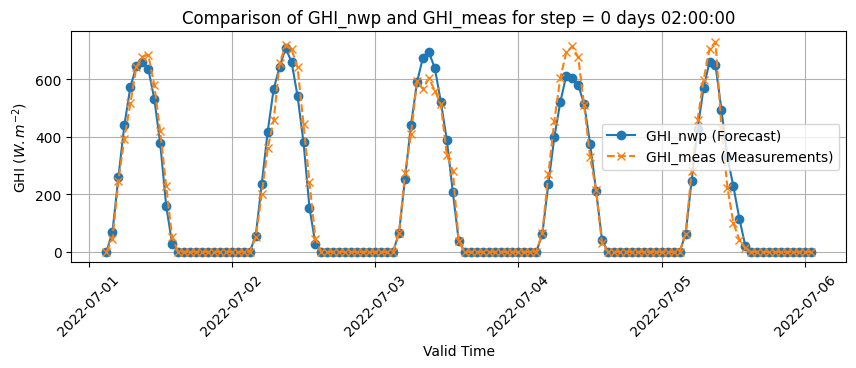

In [4]:
# Define the date range
start_date = '2022-07-01'
end_date = '2022-07-05'

# Select lead time (or step)
lt = 1

# Select the valid base_time values within the range
ds_det_slice = ds_det.sel(basetime=slice(start_date, end_date))

# Calculate the valid time of the forecasts
valid_time = ds_det_slice['basetime'] + ds_det_slice['step'].isel(step=lt)

# Plotting
plt.rcParams.update({'font.size': 10}) # Set font size
plt.figure(figsize=(10, 3))  # Set the figure size
plt.plot(valid_time, ds_det_slice['GHI_nwp'].isel(step=lt),
         marker='o', label='GHI_nwp (Forecast)')
plt.plot(valid_time, ds_det_slice['GHI_meas'].isel(step=lt),
         marker='x', linestyle='--', label='GHI_meas (Measurements)')

# Adding labels and title
plt.title('Comparison of GHI_nwp and GHI_meas for step = ' + str(pd.Timedelta(ds_det_slice['step'][lt].values)))
plt.xlabel('Valid Time')
plt.ylabel('GHI ($W.m^{-2}$)')
plt.xticks(rotation=45)
plt.legend()
plt.grid()

<h2>Exercice A.2: Scatter plot to compare forecasts and observations</h2>

A other visual tool to evaluate the correspondance between forecast and observation is the scatter plot:
* Select forecasts for one step (e.g. step 0 or 10, use different steps)
* Compare the NWP forecasts with corresponding measurements in a scatter plot

Questions
* What do you see?
* What do you extept when evaluating for one lead time only?
* Is this visual representation suitable to evaluate solar forecast?

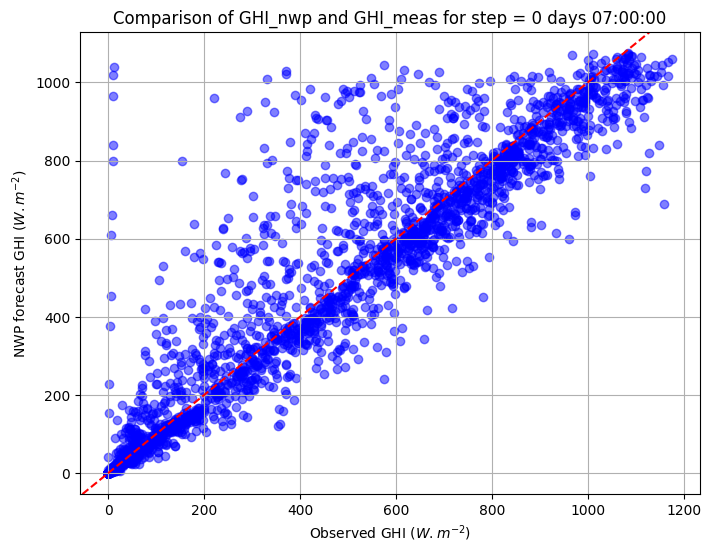

In [8]:
# Select lead time (or step)
step = 6

# Plotting
plt.rcParams.update({'font.size': 10}) # Set font size
plt.figure(figsize=(8, 6))  # Set the figure size
plt.scatter(ds_det['GHI_meas'].isel(step=step), ds_det['GHI_nwp'].isel(step=step),
            marker='o', color='blue', alpha=0.5)
plt.axline((0, 0), slope=1, color='red', linestyle='--')  # Line y=x for reference

# Adding labels and title
plt.title('Comparison of GHI_nwp and GHI_meas for step = ' + str(pd.Timedelta(ds_det_slice['step'][step].values)))
plt.xlabel('Observed GHI ($W.m^{-2}$)')
plt.ylabel('NWP forecast GHI ($W.m^{-2}$)')
plt.grid()

<h1>Section B: Evaluate forecast quality with error metrics</h1>

Beyond visual assessement, error metrics quantify the forecast quality. Using proper scores, which ensure that a better score corresponds to better quality, is very important. Usually a proper score has the following characteristics:
* Negatively oriented
* A value of 0 is a perfect forecast

<h2>A set of functions to compute quality metrics</h2>

Among the large amounts of metrics proposed to evaluate the quality of deterministic solar forecast, we will code a reduced set of 4 metrics, corresponding the most used by the scientific community:
* Mean Bias Error: $MBE = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_{i} - y_{i})$
* Mean Absolute Error: $MAE = \frac{1}{N} \sum_{i=1}^{N} |\hat{y}_{i} - y_{i}|$
* Root Mean Square Error $RMSE = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (\hat{y}_{i} - y_{i})^2}$

where $\hat{y}_{i}$ is the forecast and $y_{i}$ is the observation.

In [9]:
# Mean Bias Error
def MBE(fcst,obs):
  # fcst: forecast
  # obs: observation

  mbe = np.nanmean(fcst-obs)

  return mbe

# Mean Absolute error
def MAE(fcst,obs):
  # fcst: forecast
  # obs: observation

  mae = np.nanmean(np.abs(fcst-obs))

  return mae

# Root mean square error
def RMSE(fcst,obs):
  # fcst: forecast
  # obs: observation

  rmse = np.sqrt(np.nanmean((fcst-obs)**2))

  return rmse

<h2>Filtering of nigth GHI values</h2>

A specificity of solar irradiance is the intermittency between days and nights. Forecasting night values (no sun) is very simple and results in perfect precictions. It is thus important to not take into account for night values in the computation of error metrics. The zenith angle, which give the angle between the sun and the zenith, ranges between 0° and 90° during daytime. To remove zero night values of GHI, we filter the dataset with the zenith angle.

Question
* Find the value of zenith angle we should use to filter the data.
* Argue your choice.

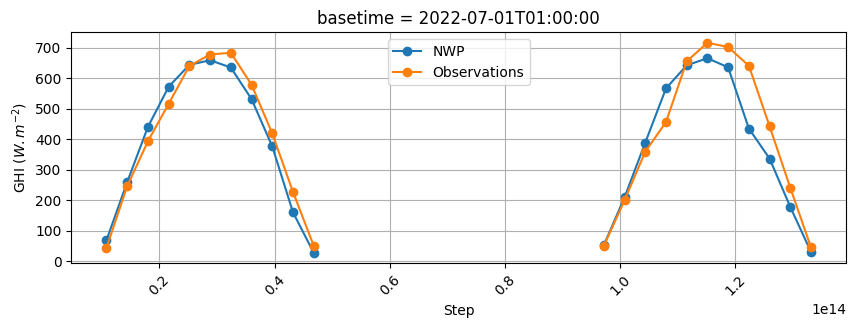

In [10]:
# Define solar zenith angle threshold
max_zenith = 90

# Create a filtered dataset ds_det_f
ds_det_f = ds_det.where(ds_det['zenith'] <= max_zenith)

# Check the results of the filtering for selected basetime
bt = 0

# Plotting
plt.rcParams.update({'font.size': 10}) # Set font size
plt.figure(figsize=(10, 3))  # Set the figure size
ds_det_f['GHI_nwp'].isel(basetime=bt).plot(marker='o', label='NWP')
ds_det_f['GHI_meas'].isel(basetime=bt).plot(marker='o', label='Observations')
plt.xlabel('Step')
plt.ylabel('GHI ($W.m^{-2}$)')
plt.xticks(rotation=45)
plt.legend()
plt.grid()

<h2>Exercice B.1: Compute the MBE for the 1st stpf of the NWP GHI forecast</h2>

To compute the of the 1st step of the NWP:
* Select the step
* Extract the GHI forecast from the dataset ds_det_f
* Extract the corresponding measured GHI from the dataset ds_det_f
* Compute the MBE

Questions
* What are the units of the MBE?
* Are the NWP forecasts close to observations?
* What type of bias does the NWP forecast exhibit?

In [14]:
# Select step
step = 0

# Extract NWP GHI forecast for selected step
ghi_nwp = ds_det_f['GHI_nwp'].isel(step=step).values

# Extract measured GHI  for selected step
ghi_meas = ds_det_f['GHI_meas'].isel(step=step).values

# Compute MBE
mbe_nwp = MBE(ghi_nwp,ghi_meas)

print('MBE = ', mbe_nwp)

MBE =  14.055244276201424


<h2>Exercice B.2: Plot the MBE of the NWP forecast along the lead time</h2>

It is common practice to assess the evolution of the error metrics along the lead time. As the weather, and consequently the solar irradiance, is a chaotic process, the forecast qualitity tends to decrease with increasing time horizons.

To generate such a plot:
* Loop on the step dimension of the dataset
* Compute the error metric (here the MBE) at each loop
* Display the results

Questions
* Does the quality, in terms of MBE, changes along the lead time?
* Comment on the shape of MBE evolution.


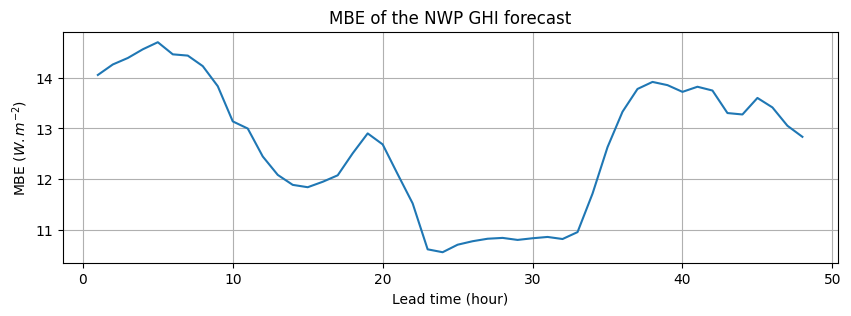

In [15]:
# Create a empty pandas DataFrame to store the results
df_metric_nwp = pd.DataFrame(columns = ['step', 'MBE'])

# Loop on the step dimension
for i, st in enumerate(ds_det_f.step):
  dum_mbe = MBE(ds_det_f['GHI_nwp'].sel(step=st).values, ds_det_f['GHI_meas'].sel(step=st).values)
  df_metric_nwp.loc[i] = [i+1, dum_mbe]

# Plotting
plt.rcParams.update({'font.size': 10}) # Set font size
plt.figure(figsize=(10, 3))  # Set the figure size
plt.plot(df_metric_nwp['step'], df_metric_nwp['MBE'])

# Adding labels and title
plt.title('MBE of the NWP GHI forecast')
plt.xlabel('Lead time (hour)')
plt.ylabel('MBE ($W.m^{-2}$)')
plt.grid()

<h2>Exercice B.3: Plot the MAE and RMSE of the NWP forecast along the lead time</h2>

Use the same method as previously for the MBE to compute the MAE and RMSE.

Questions
* Does the quality, in terms of MAE and RMSE, changes along the lead time?

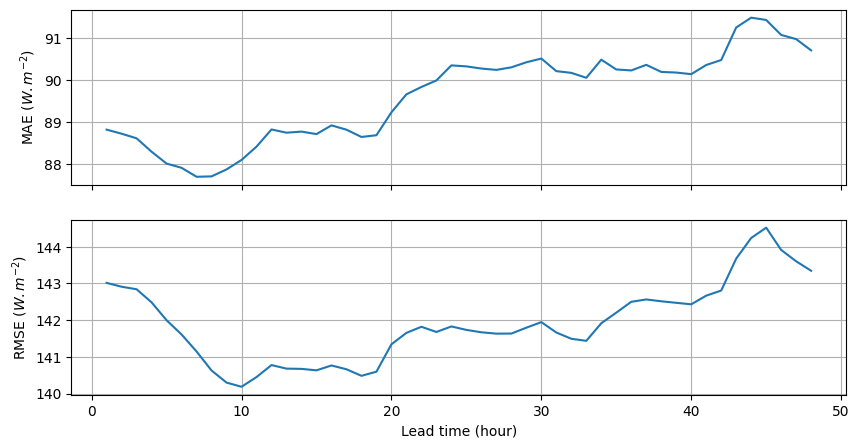

In [17]:
# Add column to df_metric_nwp to store the results
df_metric_nwp['MAE'] = np.nan
df_metric_nwp['RMSE'] = np.nan

# Loop on the step dimension
for i, st in enumerate(ds_det_f.step):

  # Add here the code to compute the MAE and RMSE

  df_metric_nwp.loc[i, 'MAE'] = MAE(ds_det_f['GHI_nwp'].sel(step=st).values, ds_det_f['GHI_meas'].sel(step=st).values) # Compute MAE
  df_metric_nwp.loc[i, 'RMSE'] = RMSE(ds_det_f['GHI_nwp'].sel(step=st).values, ds_det_f['GHI_meas'].sel(step=st).values) # Compute MAE

# Plotting
plt.rcParams.update({'font.size': 10}) # Set font size
fig, (ax1, ax2) = plt.subplots(2, sharex=True, figsize=(10, 5))
ax1.plot(df_metric_nwp['step'], df_metric_nwp['MAE'])
ax1.set_ylabel('MAE ($W.m^{-2}$)')
ax1.grid()

ax2.plot(df_metric_nwp['step'], df_metric_nwp['RMSE'])
ax2.set_xlabel('Lead time (hour)')
ax2.set_ylabel('RMSE ($W.m^{-2}$)')
ax2.grid()

<h2>Exercice B.4: Relative error metrics</h2>

The amount of solar irradiance can differ between the different lead times. As a consequence, comparing absolute metric values is not fair. To be sure work with comparable values, it is thus important to use relative values of error metrics. In other words, we should divide the absolute error metrics by a consitent reference.

Question
* What is the best reference to use to derive relative error metrics of GHI forecast quality?

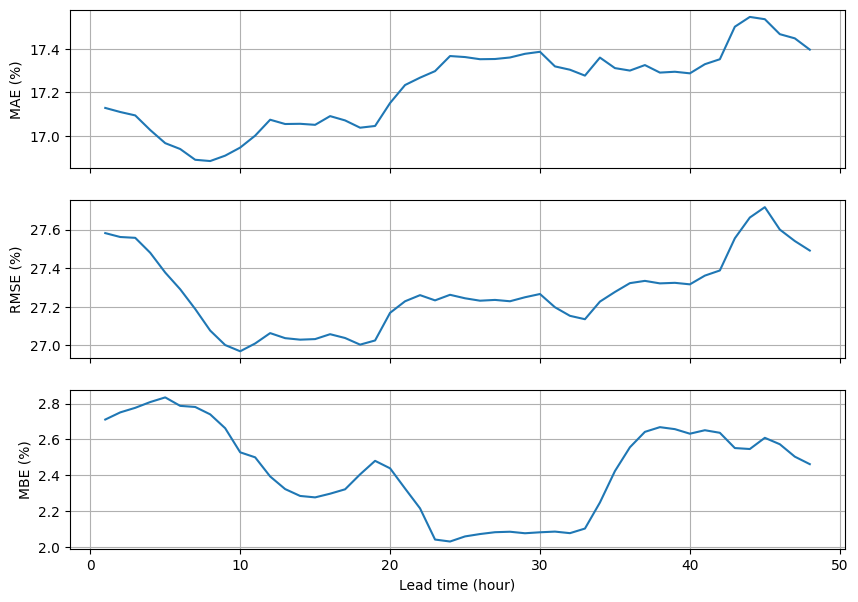

In [19]:
# Compute the value used to normalize the metrics
df_metric_nwp['Norm'] = np.nan

for i, st in enumerate(ds_det_f.step):
  df_metric_nwp.loc[i, 'Norm'] = np.nanmean(ds_det_f['GHI_meas'].sel(step=st).values) # Add here the code to compute refernce value needed to normalize the metrics

# Plotting
plt.rcParams.update({'font.size': 10}) # Set font size
fig, (ax1, ax2, ax3) = plt.subplots(3, sharex=True, figsize=(10, 7))
ax1.plot(df_metric_nwp['step'], df_metric_nwp['MAE']/df_metric_nwp['Norm']*100)
ax1.set_ylabel('MAE (%)')
ax1.grid()

ax2.plot(df_metric_nwp['step'], df_metric_nwp['RMSE']/df_metric_nwp['Norm']*100)
ax2.set_ylabel('RMSE (%)')
ax2.grid()

ax3.plot(df_metric_nwp['step'], df_metric_nwp['MBE']/df_metric_nwp['Norm']*100)
ax3.set_xlabel('Lead time (hour)')
ax3.set_ylabel('MBE (%)')
ax3.grid()

<h2>Compare the quality of the different forecasting models (NWP, Satellite and persistence)</h2>

In the dataset, 3 forecasting models are present: NWP, Satellite and smart persistence. Compute the error metrics of all the forecasting models and compare them:
*   Loop on the model and lead time to compute the error metrics
*   Plot the results on the same plots

Questions
* Does this comparaison change your opinion on the quality of the NWP forecast?
* What is the best degterminsitic forecasting model?

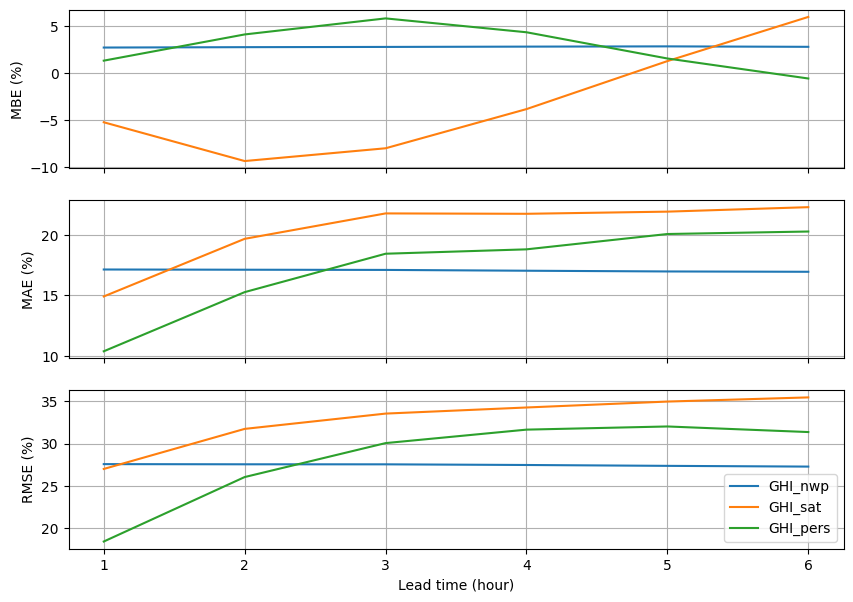

In [20]:
# Create a empty pandas DataFrame to store the results
df_mbe = pd.DataFrame(columns = ['step', 'GHI_nwp', 'GHI_sat', 'GHI_pers'])
df_mae = pd.DataFrame(columns = ['step', 'GHI_nwp', 'GHI_sat', 'GHI_pers'])
df_rmse = pd.DataFrame(columns = ['step', 'GHI_nwp', 'GHI_sat', 'GHI_pers'])

# Loop on the step dimension and models
for st in np.arange(6): #ds_det_f.sizes['step']):
  df_mbe.loc[st, 'step'] = st+1
  df_mae.loc[st, 'step'] = st+1
  df_rmse.loc[st, 'step'] = st+1
  for mod in ['GHI_nwp', 'GHI_sat', 'GHI_pers']:
    fcst = ds_det_f[mod].isel(step=st).values
    obs = ds_det_f['GHI_meas'].isel(step=st).values
    df_mbe.loc[st, mod] = MBE(fcst,obs)/np.nanmean(obs)*100
    df_mae.loc[st, mod] = MAE(fcst,obs)/np.nanmean(obs)*100
    df_rmse.loc[st, mod] = RMSE(fcst,obs)/np.nanmean(obs)*100

# Plotting
plt.rcParams.update({'font.size': 10}) # Set font size
fig, (ax1, ax2, ax3) = plt.subplots(3, sharex=True, figsize=(10, 7))
for mod in ['GHI_nwp', 'GHI_sat', 'GHI_pers']:
  ax1.plot(df_mbe['step'], df_mbe[mod], label=mod)
ax1.set_ylabel('MBE (%)')
ax1.grid()

for mod in ['GHI_nwp', 'GHI_sat', 'GHI_pers']:
  ax2.plot(df_mae['step'], df_mae[mod], label=mod)
ax2.set_ylabel('MAE (%)')
ax2.grid()

for mod in ['GHI_nwp', 'GHI_sat', 'GHI_pers']:
  ax3.plot(df_rmse['step'], df_rmse[mod], label=mod)
ax3.set_xlabel('Lead time (hour)')
ax3.set_ylabel('RMSE (%)')
ax3.legend()
ax3.grid()

<h1>------------------------------------------------------</h1>

<h1>Go beyond</h1>

If you want to learn more on deterministic forecasting, like how to blend different forecasting sources, you can visit the online courses created for the [TwInSolar](https://twinsolar.eu/) summer school:
* GitHub repository with the data: [TwInSolar-Summer_shool_data](https://github.com/Laboratoire-Piment/TwInSolar-Summer_shool_data)
* Google Drive reposotory to access slideshows and Jupyter Nore books: [TwInSolar_Summer_school_11-2024](https://drive.google.com/drive/folders/1zsrVPdHo_bujXX9OJfDZJQwq8fJk8sUJ?usp=sharing)